In [ ]:
!pip -q install xlrd==2.0.1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving default of credit card clients.xls to default of credit card clients (4).xls


In [ ]:
FILE = "default of credit card clients.xls"
df_raw = pd.read_excel(FILE)

print("Shape:", df_raw.shape)
df_raw.head()

Shape: (30001, 25)


,Unnamed: 0,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18,X19,X20,X21,X22,X23,Y
0,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
1,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
2,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
3,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
4,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0


In [ ]:
df = df_raw.copy()
df.columns = [str(c).strip().replace("\n", " ") for c in df.columns]
print(df.columns.tolist())

['Unnamed: 0', 'X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'X9', 'X10', 'X11', 'X12', 'X13', 'X14', 'X15', 'X16', 'X17', 'X18', 'X19', 'X20', 'X21', 'X22', 'X23', 'Y']


In [ ]:
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

y_col = "Y"

print("Using target column:", y_col)

Using target column: Y


In [ ]:
df.columns = [str(c).strip().replace("\n", " ") for c in df.columns]

if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape before removing label row:", df.shape)

df = df.iloc[1:].reset_index(drop=True)

print("Shape after removing label row:", df.shape)

df["Y"] = df["Y"].astype(int)

Shape before removing label row: (30001, 24)
Shape after removing label row: (30000, 24)


In [ ]:
counts = df[y_col].value_counts().sort_index()
counts

,count
Y,
0,23364
1,6636


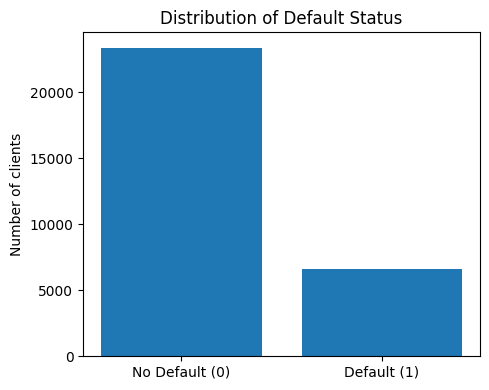

In [ ]:
plt.figure(figsize=(5,4))
plt.bar(["No Default (0)", "Default (1)"], [counts[0], counts[1]])
plt.ylabel("Number of clients")
plt.title("Distribution of Default Status")
plt.tight_layout()
plt.savefig("fig1_class_balance.png", dpi=200)
plt.show()

/tmp/ipython-input-480339375.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data0, data1], labels=["No Default (0)", "Default (1)"], showfliers=False)


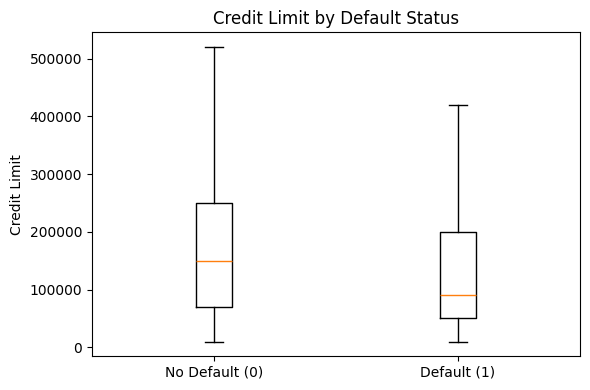

In [ ]:
data0 = df.loc[df["Y"] == 0, "X1"]
data1 = df.loc[df["Y"] == 1, "X1"]

plt.figure(figsize=(6,4))
plt.boxplot([data0, data1], labels=["No Default (0)", "Default (1)"], showfliers=False)
plt.ylabel("Credit Limit")
plt.title("Credit Limit by Default Status")
plt.tight_layout()
plt.savefig("fig2_credit_limit_boxplot.png", dpi=200)
plt.show()

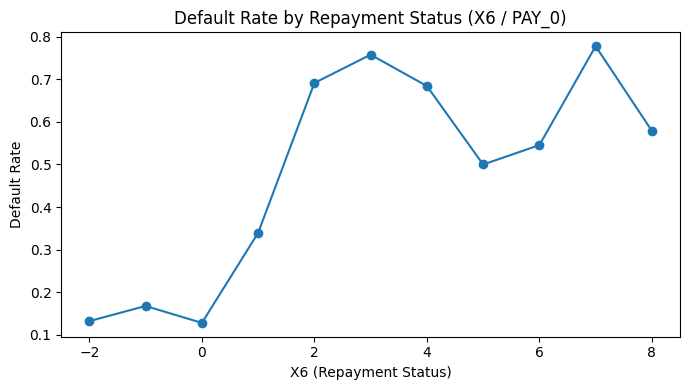

,count,default_rate
X6,,
-2,2759,0.132294
-1,5686,0.167781
0,14737,0.128113
1,3688,0.339479
2,2667,0.691414
3,322,0.757764
4,76,0.684211
5,26,0.500000
6,11,0.545455


In [ ]:
rate_by_x6 = df.groupby("X6")["Y"].mean().sort_index()
count_by_x6 = df["X6"].value_counts().sort_index()

plt.figure(figsize=(7,4))
plt.plot(rate_by_x6.index, rate_by_x6.values, marker="o")
plt.xlabel("X6 (Repayment Status)")
plt.ylabel("Default Rate")
plt.title("Default Rate by Repayment Status (X6 / PAY_0)")
plt.tight_layout()
plt.savefig("fig3_default_rate_by_pay0.png", dpi=200)
plt.show()

summary_x6 = pd.DataFrame({
    "count": count_by_x6,
    "default_rate": rate_by_x6
})
summary_x6